# Value-recurrence (AR) analysis of the SB3 runs — Acrobot

Every SB3 comparison run records the **autoregressive value probe** during
training (`analysis.autoregressive_value_probe` in `configs/config_sb3.yaml`,
dispatched through the same `training.run_analysis_tick` as the classic runs):
every `analysis.ep_freq` episodes the policy is frozen, rolled greedily from
fixed probe seeds recording V(s) (for QR-DQN, the quantile-mean value), and one
global AR recurrence is fitted per order under two splits (held-out
trajectories; prefix/suffix) and two regimes (one-step-ahead; rolling
forecasts re-anchored every tau steps).

This notebook renders those artifacts through the standard plotting suite
(`src/analysis/visualisations/autoregressive_value_plots.py`) for one run —
switch `ARM` / `SEED_IDX` below to inspect any arm of the manifest (e.g. an
`exp<N>` arm to see whether the FHR penalty tightens the fitted recurrence).
Launch runs first via `exp1_sb3_fhrdqn_compare.ipynb` or
`../src/run_sb3_seeds.py`; probe artifacts can also be (re)generated on any
checkpoint post-hoc with `../src/run_sb3_analysis.py`.

In [1]:
import sys, pathlib
import pandas as pd

EXPS = pathlib.Path.cwd().parent / "src"       # stable_baselines_3/src
SRC = pathlib.Path.cwd().parents[2] / "src"   # repo library code
for p in (str(EXPS), str(SRC)):
    if p not in sys.path:
        sys.path.insert(0, p)

from run_sb3_seeds import load_runs
import analysis.visualisations.autoregressive_value_plots as value_plots

In [2]:
ARM = "baseline"      # "baseline" or any "exp<N>" arm of the manifest
SEED_IDX = 0          # index into experiment.seeds

run = load_runs(ARM)[SEED_IDX]
run_directory = run["run_dir"]
checkpoints = value_plots.available_rollout_episodes(run_directory)
ORDERS = value_plots.available_orders(run_directory)
FITTED_INTERCEPT = value_plots.fitted_with_intercept(run_directory)
print(f"{ARM} seed {run['seed']}: {run_directory.name}")
print(f"probe checkpoints: {checkpoints}")
print(f"orders: {ORDERS} | fitted with intercept: {FITTED_INTERCEPT}")

baseline seed 44: sb3_acrobot_baseline_seed44_20260819-214637
probe checkpoints: [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]
orders: [2, 3, 4] | fitted with intercept: False


## Learning curve with probe checkpoints

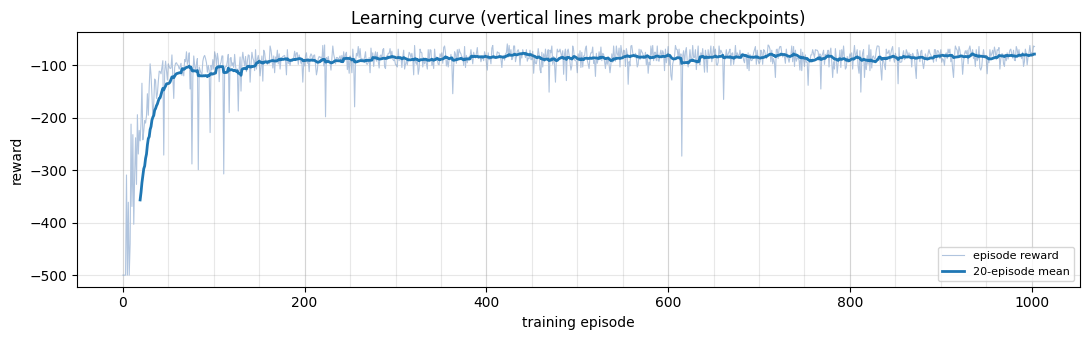

In [3]:
value_plots.plot_reward_with_checkpoints(run_directory);

## Prediction error over training

One column per AR order, train/test rows, one line per forecast window tau
(log scale). First the held-out-trajectory split, then prefix/suffix.

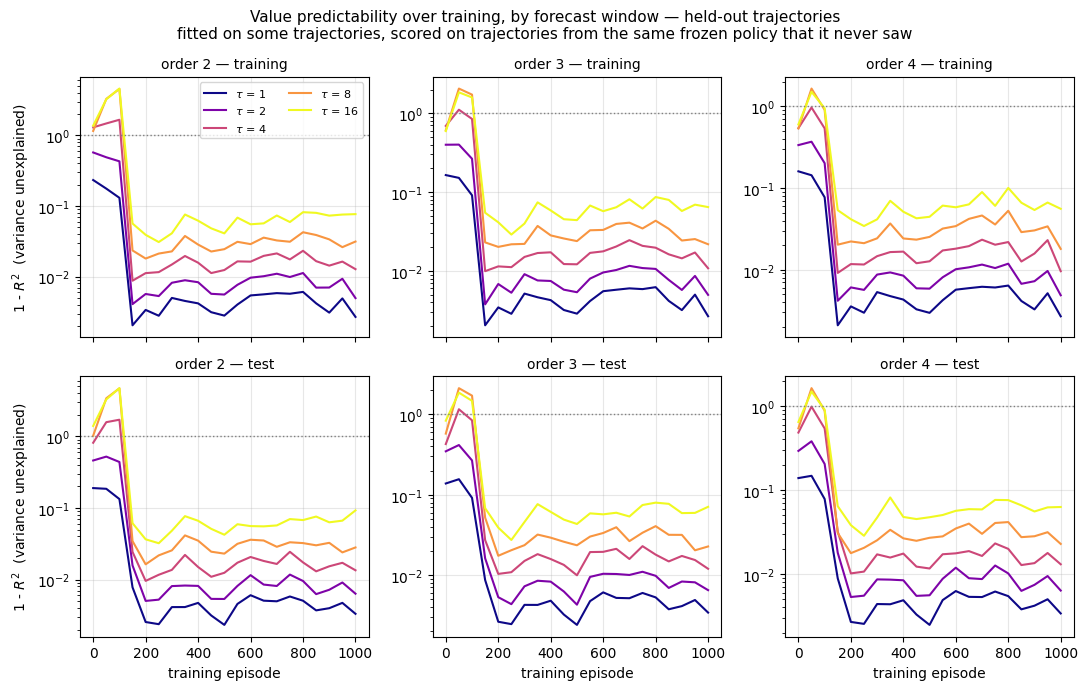

In [4]:
value_plots.plot_prediction_error_over_training(
    run_directory, split=value_plots.HELD_OUT_TRAJECTORY_SPLIT);

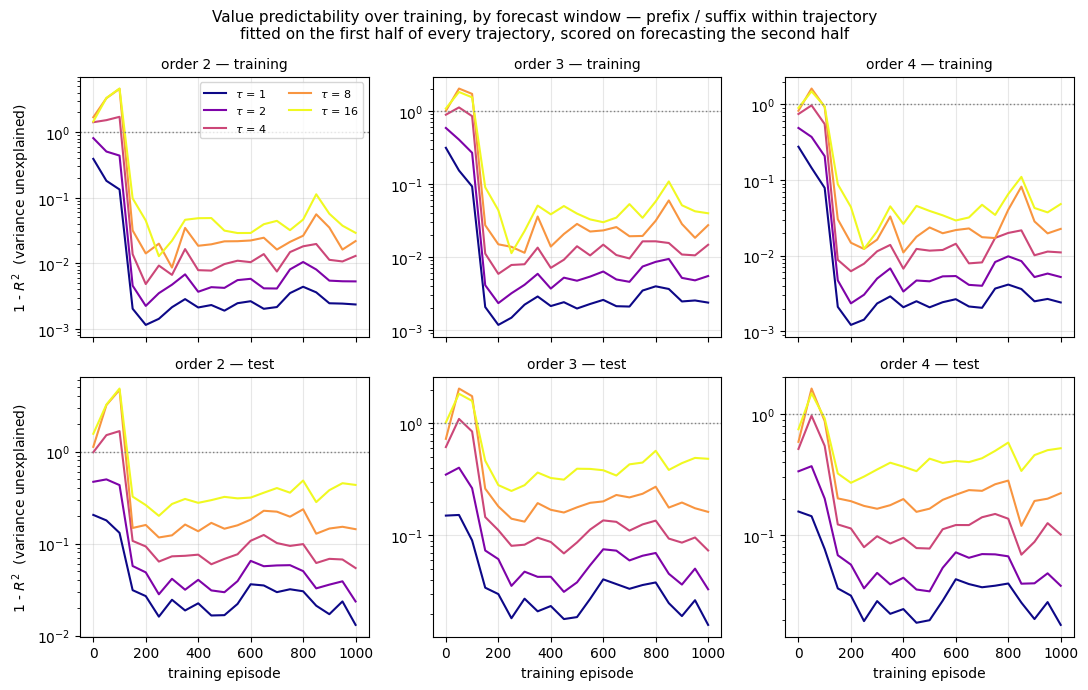

In [5]:
value_plots.plot_prediction_error_over_training(
    run_directory, split=value_plots.PREFIX_SUFFIX_SPLIT);

## Final-checkpoint fit quality

In [6]:
value_plots.summarise_final_checkpoint(run_directory).round(4)

,tau=1,tau=2,tau=4,tau=8,tau=16
order,,,,,
2,0.0033,0.0063,0.0135,0.0281,0.0926
3,0.0034,0.0065,0.0120,0.0227,0.0707
4,0.0034,0.0063,0.0131,0.0228,0.0628


In [7]:
value_plots.summarise_final_checkpoint(run_directory, metric="rmse").round(6)

,tau=1,tau=2,tau=4,tau=8,tau=16
order,,,,,
2,0.837323,1.157593,1.686941,2.435953,4.422863
3,0.840677,1.159926,1.575905,2.170128,3.832018
4,0.831412,1.138035,1.631753,2.156680,3.579537


## Error versus forecast horizon

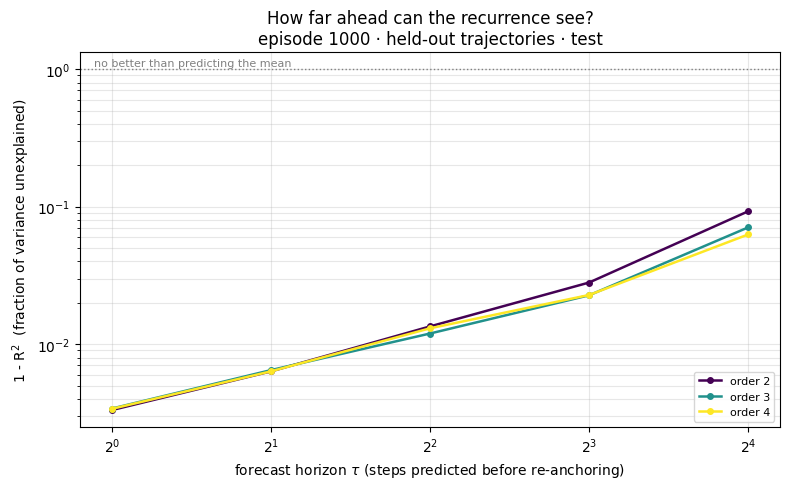

In [8]:
value_plots.plot_error_versus_forecast_horizon(run_directory);

In [9]:
value_plots.summarise_horizon_sweep(run_directory, subset="training").round(4)

,tau=1,tau=2,tau=4,tau=8,tau=16
order,,,,,
2,0.0027,0.0050,0.0128,0.0314,0.0768
3,0.0027,0.0050,0.0108,0.0218,0.0646
4,0.0027,0.0049,0.0096,0.0180,0.0557


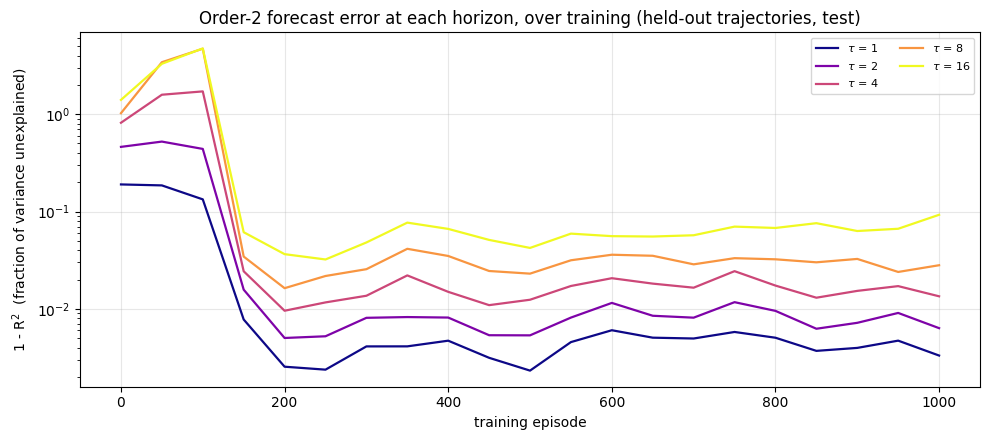

In [10]:
value_plots.plot_horizon_error_over_training(run_directory, order=ORDERS[0]);

## Fitted recurrence coefficients over training

Per-lag coefficients with the dashed sum-of-lags; a sum near 1 with a stable
low-order fit is the Kronecker signature of low Hankel rank (compare against
the `fhr_order` an exp arm penalises toward).

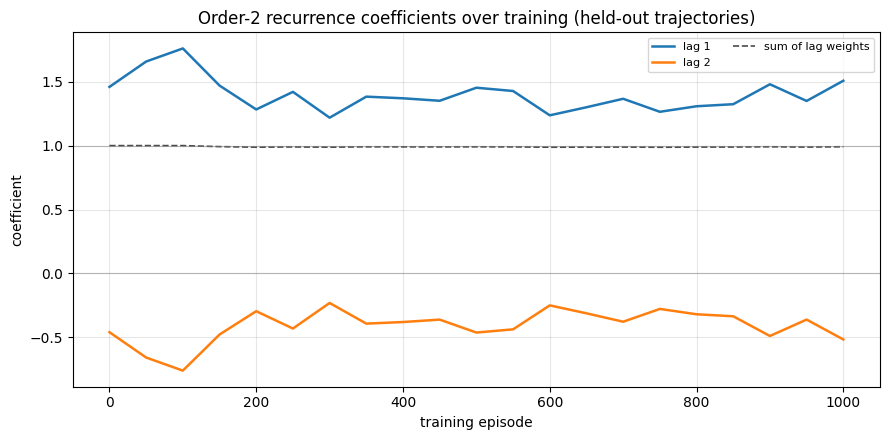

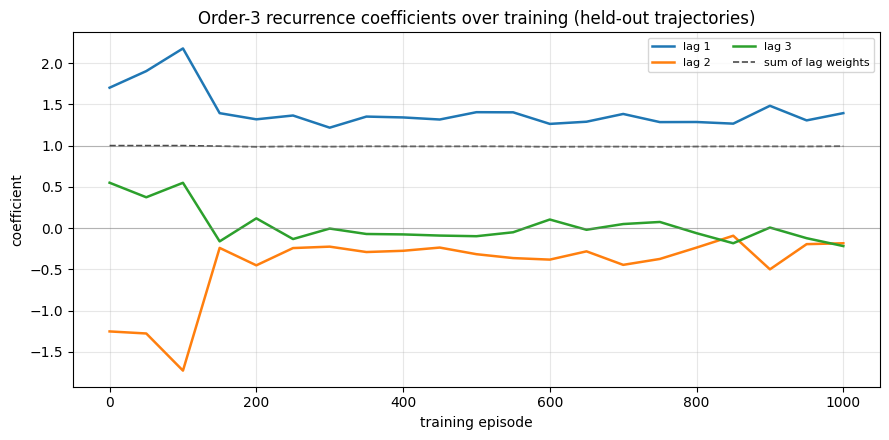

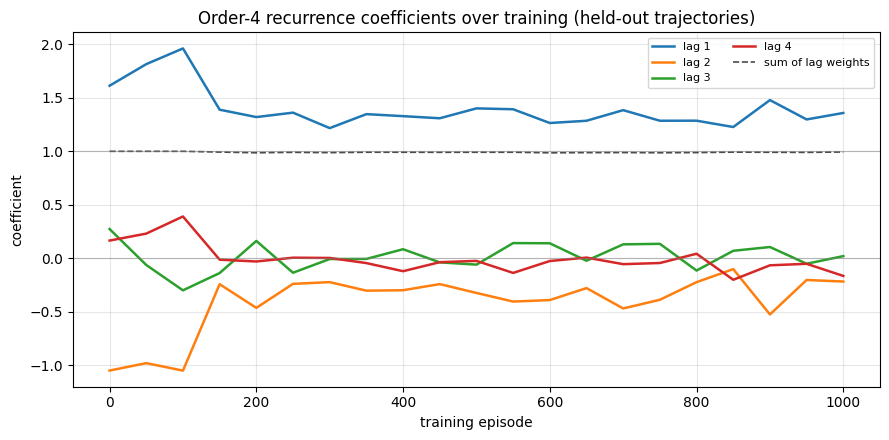

In [11]:
for order in ORDERS:
    value_plots.plot_coefficient_evolution(run_directory, order,
                                           include_intercept=FITTED_INTERCEPT)

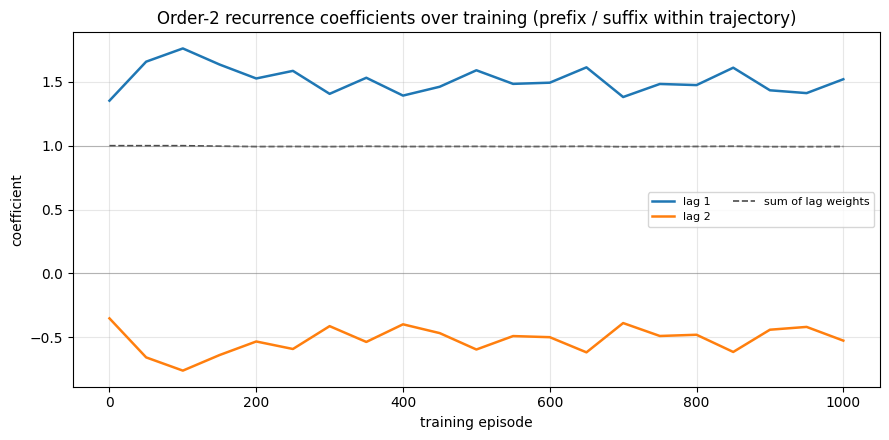

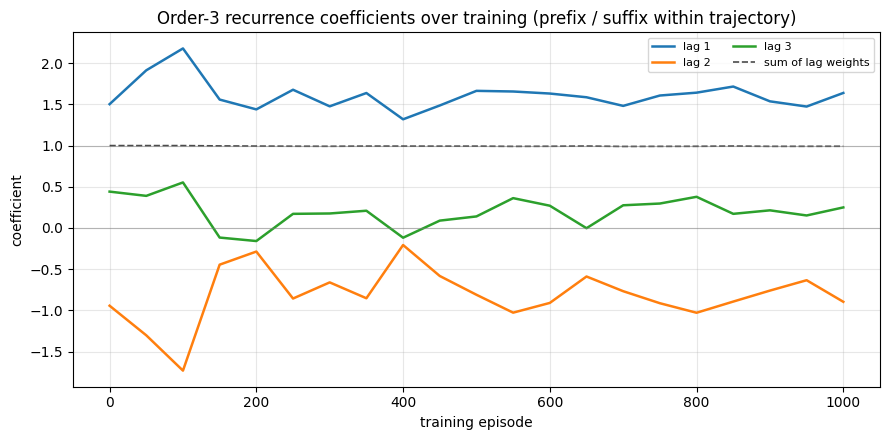

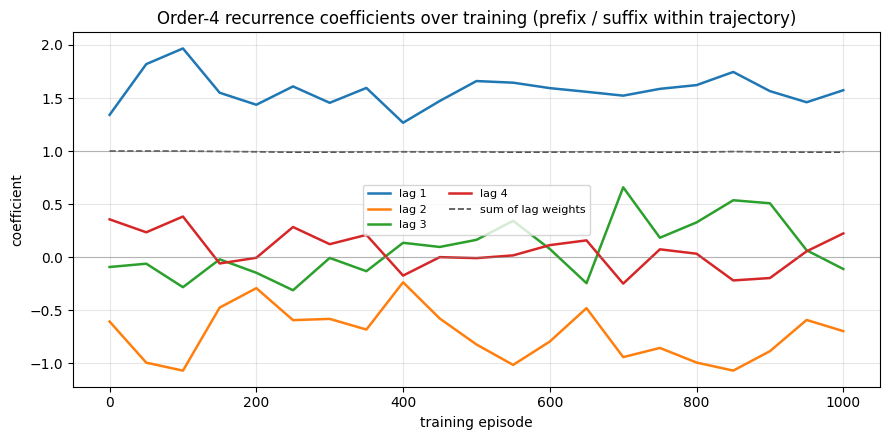

In [12]:
for order in ORDERS:
    value_plots.plot_coefficient_evolution(run_directory, order,
                                           include_intercept=FITTED_INTERCEPT,
                                           split=value_plots.PREFIX_SUFFIX_SPLIT)

## Example rollouts: actual vs one-step vs rolling forecasts

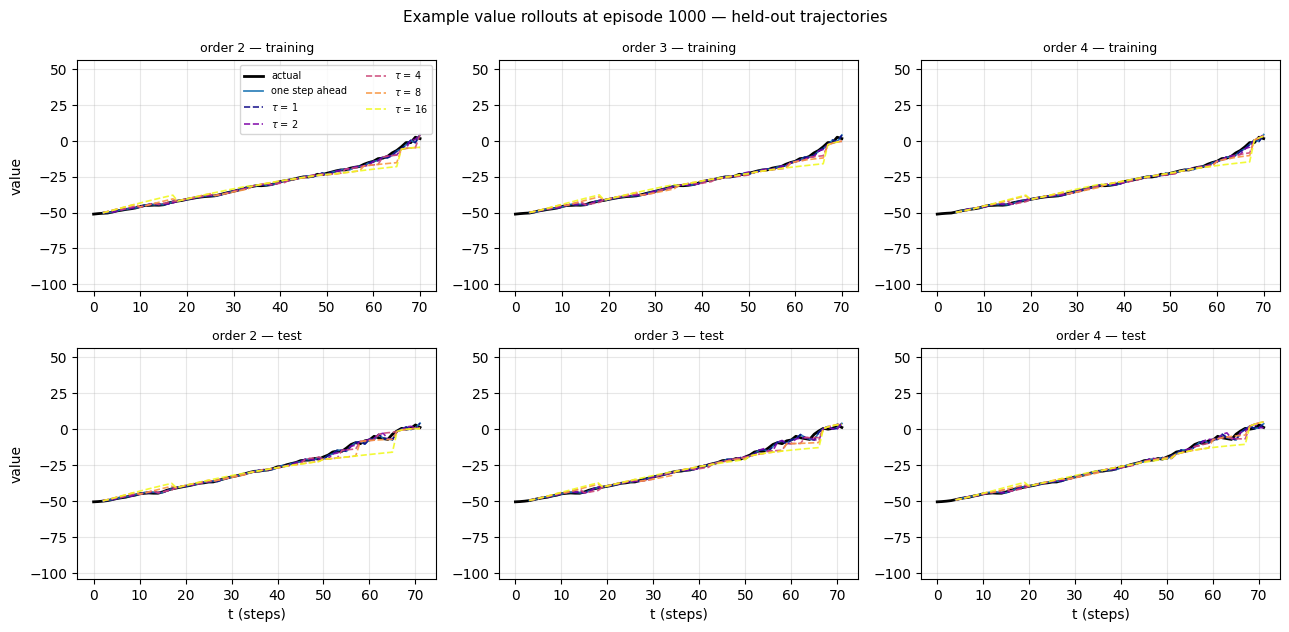

In [13]:
value_plots.plot_example_rollouts(run_directory);

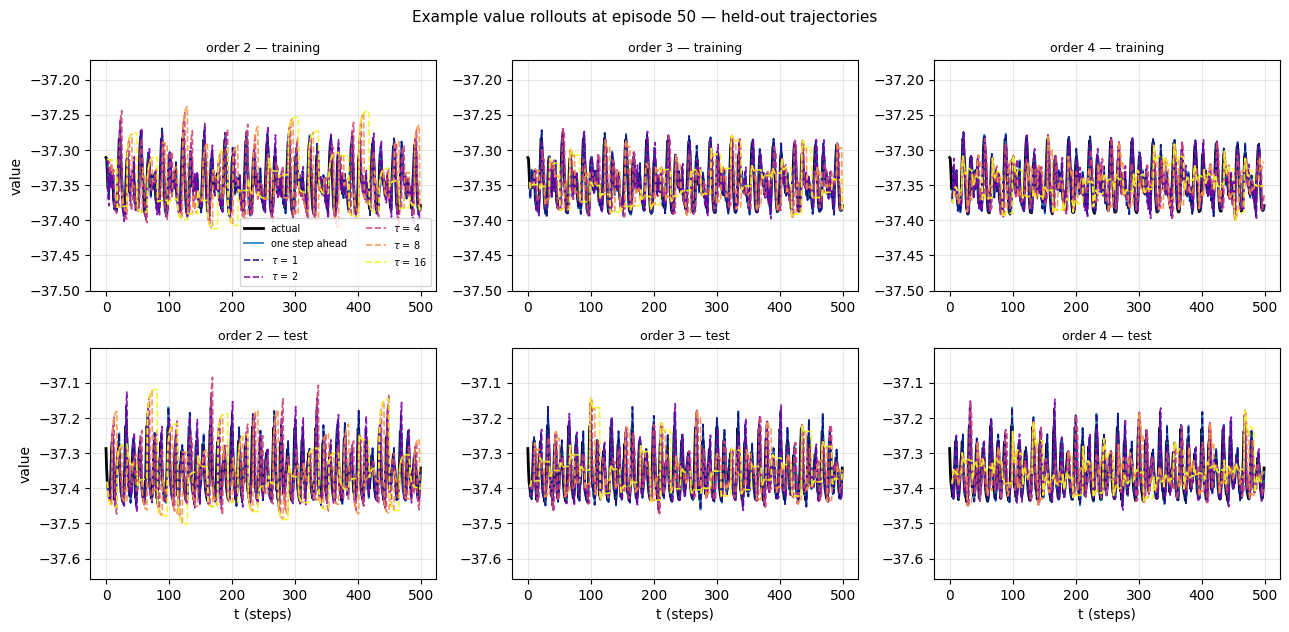

In [14]:
if len(checkpoints) > 1:
    value_plots.plot_example_rollouts(run_directory, episode=checkpoints[1])

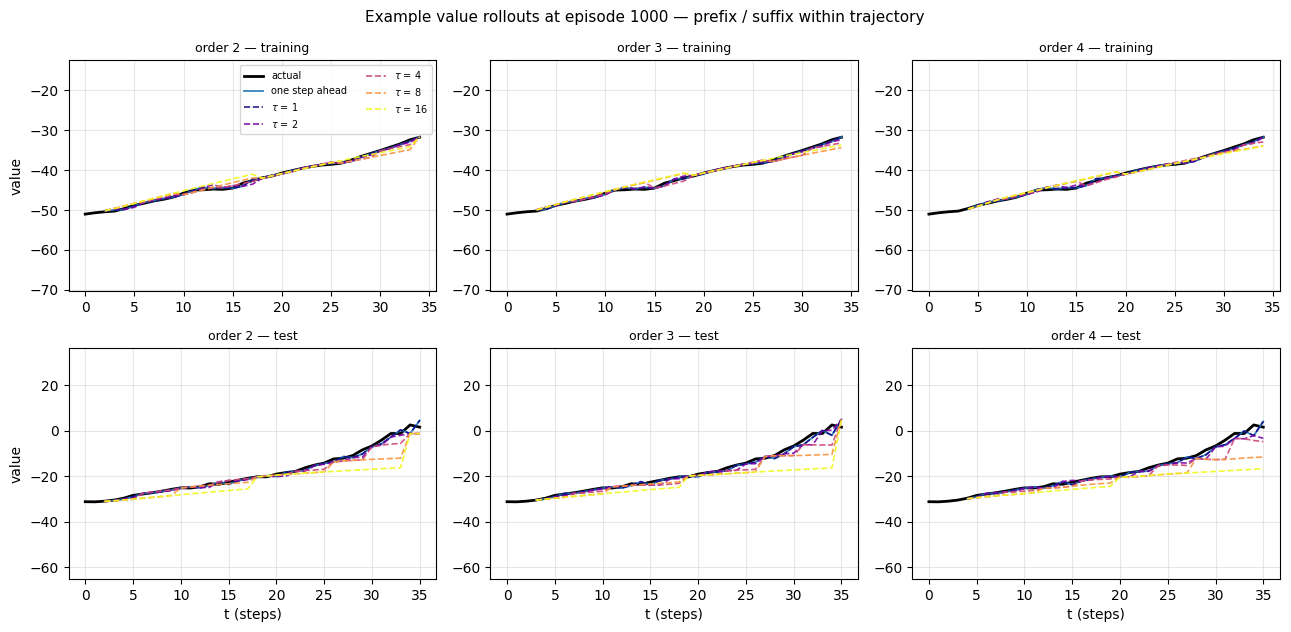

In [15]:
value_plots.plot_example_rollouts(run_directory,
                                  split=value_plots.PREFIX_SUFFIX_SPLIT);

## Raw metrics peek

In [16]:
pd.read_csv(run_directory / "autoregressive_value_metrics.csv").tail(8)

,episode,order,split,subset,rmse_one_step_ahead,one_minus_r_squared_one_step_ahead,n_sequences_scored,n_trajectories_collected,mean_trajectory_length
244,1000,3,held_out_trajectory_split,training,0.723452,0.002663,24,40,68.3
245,1000,3,held_out_trajectory_split,test,0.840677,0.003403,16,40,68.3
246,1000,3,prefix_suffix_split,training,0.261306,0.002364,40,40,68.3
247,1000,3,prefix_suffix_split,test,1.175944,0.015909,40,40,68.3
248,1000,4,held_out_trajectory_split,training,0.720548,0.002691,24,40,68.3
249,1000,4,held_out_trajectory_split,test,0.831412,0.003388,16,40,68.3
250,1000,4,prefix_suffix_split,training,0.257047,0.002406,40,40,68.3
251,1000,4,prefix_suffix_split,test,1.240220,0.018326,40,40,68.3
